# Provided code

In [1]:
mode = "colab" # change this to "local" if you are on your own computer

if mode == "local":
    import models
elif mode == "colab":
    import requests
    url = 'https://github.com/ahmadianlab/gg3_nda/blob/main/models.py?raw=true'
    r = requests.get(url)
    with open('models.py', 'w') as f:
        f.write(r.text)
    import models
else:
    raise Exception("mode must be either local or colab")

In [2]:
import numpy as np
import numpy.random as npr


def lo_histogram(x, bins):
    """
    Left-open version of np.histogram with left-open bins covering the interval (left_edge, right_edge]
    (np.histogram does the opposite and treats bins as right-open.)
    Input & output behaviour is exactly the same as np.histogram
    """
    out = np.histogram(-x, -bins[::-1])
    return out[0][::-1], out[1:]


def gamma_isi_point_process(rate, shape):
    """
    Simulates (1 trial of) a sub-poisson point process (with underdispersed inter-spike intervals relative to Poisson)
    :param rate: time-series giving the mean spike count (firing rate * dt) in different time bins (= time steps)
    :param shape: shape parameter of the gamma distribution of ISI's
    :return: vector of spike counts with same shape as "rate".
    """
    sum_r_t = np.hstack((0, np.cumsum(rate)))
    gs = np.zeros(2)
    while gs[-1] < sum_r_t[-1]:
        gs = np.cumsum( npr.gamma(shape, 1 / shape, size=(2 + int(2 * sum_r_t[-1]),)) )
    y, _ = lo_histogram(gs, sum_r_t)

    return y



class StepModel():
    """
    Simulator of the Stepping Model of Latimer et al. Science 2015.
    """
    def __init__(self, m=50, r=10, x0=0.2, Rh=50, isi_gamma_shape=None, Rl=None, dt=None):
        """
        Simulator of the Stepping Model of Latimer et al. Science 2015.
        :param m: mean jump time (in # of time-steps). This is the mean parameter of the Negative Binomial distribution
                  of jump (stepping) time
        :param r: parameter r ("# of successes") of the Negative Binomial (NB) distribution of jump (stepping) time
                  (Note that it is more customary to parametrise the NB distribution by its parameter p and r,
                  instead of m and r, where p is so-called "probability of success" (see Wikipedia). The two
                  parametrisations are equivalent and one can go back-and-forth via: m = r (1-p)/p and p = r / (m + r).)
        :param x0: determines the pre-jump firing rate, via  R_pre = x0 * Rh (see below for Rh)
        :param Rh: firing rate of the "up" state (the same as the post-jump state in most of the project tasks)
        :param isi_gamma_shape: shape parameter of the Gamma distribution of inter-spike intervals.
                            see https://en.wikipedia.org/wiki/Gamma_distribution
        :param Rl: firing rate of the post-jump "down" state (rarely used)
        :param dt: real time duration of time steps in seconds (only used for converting rates to units of inverse time-step)
        """
        self.m = m
        self.r = r
        self.x0 = x0

        self.p = r / (m + r)

        self.Rh = Rh
        if Rl is not None:
            self.Rl = Rl

        self.isi_gamma_shape = isi_gamma_shape
        self.dt = dt


    @property
    def params(self):
        return self.m, self.r, self.x0

    @property
    def fixed_params(self):
        return self.Rh, self.Rl


    def emit(self, rate):
        """
        emit spikes based on rates
        :param rate: firing rate sequence, r_t, possibly in many trials. Shape: (Ntrials, T)
        :return: spike train, n_t, as an array of shape (Ntrials, T) containing integer spike counts in different
                 trials and time bins.
        """
        if self.isi_gamma_shape is None:
            # poisson spike emissions
            y = npr.poisson(rate * self.dt)
        else:
            # sub-poisson/underdispersed spike emissions
            y = gamma_isi_point_process(rate * self.dt, self.isi_gamma_shape)

        return y


    def simulate(self, Ntrials=1, T=100, get_rate=True):
        """
        :param Ntrials: (int) number of trials
        :param T: (int) duration of each trial in number of time-steps.
        :param get_rate: whether or not to return the rate time-series
        :return:
        spikes: shape = (Ntrial, T); spikes[j] gives the spike train, n_t, in trial j, as
                an array of spike counts in each time-bin (= time step)
        jumps:  shape = (Ntrials,) ; jumps[j] is the jump time (aka step time), tau, in trial j.
        rates:  shape = (Ntrial, T); rates[j] is the rate time-series, r_t, in trial j (returned only if get_rate=True)
        """
        # set dt (time-step duration in seconds) such that trial duration is always 1 second, regardless of T.
        dt = 1 / T
        self.dt = dt

        ts = np.arange(T)

        spikes, jumps, rates = [], [], []
        for tr in range(Ntrials):
            # sample jump time
            jump = npr.negative_binomial(self.r, self.p)
            jumps.append(jump)

            # first set rate at all times to pre-step rate
            rate = np.ones(T) * self.x0 * self.Rh
            # then set rates after jump to self.Rh
            rate[ts >= jump] = self.Rh
            rates.append(rate)

            spikes.append(self.emit(rate))

        if get_rate:
            return np.array(spikes), np.array(jumps), np.array(rates)
        else:
            return np.array(spikes), np.array(jumps)


class RampModel():
    """
    Simulator of the Ramping Model (aka Drift-Diffusion Model) of Latimer et al., Science (2015).
    """
    def __init__(self, beta=0.5, sigma=0.2, x0=.2, Rh=50, isi_gamma_shape=None, Rl=None, dt=None):
        """
        Simulator of the Ramping Model of Latimer et al. Science 2015.
        :param beta: drift rate of the drift-diffusion process
        :param sigma: diffusion strength of the drift-diffusion process.
        :param x0: average initial value of latent variable x[0]
        :param Rh: the maximal firing rate obtained when x_t reaches 1 (corresponding to the same as the post-step
                   state in most of the project tasks)
        :param isi_gamma_shape: shape parameter of the Gamma distribution of inter-spike intervals.
                            see https://en.wikipedia.org/wiki/Gamma_distribution
        :param Rl: Not implemented. Ignore.
        :param dt: real time duration of time steps in seconds (only used for converting rates to units of inverse time-step)
        """
        self.beta = beta
        self.sigma = sigma
        self.x0 = x0

        self.Rh = Rh
        if Rl is not None:
            self.Rl = Rl

        self.isi_gamma_shape = isi_gamma_shape
        self.dt = dt


    @property
    def params(self):
        return self.mu, self.sigma, self.x0

    @property
    def fixed_params(self):
        return self.Rh, self.Rl


    def f_io(self, xs, b=None):
        if b is None:
            return self.Rh * np.maximum(0, xs)
        else:
            return self.Rh * b * np.log(1 + np.exp(xs / b))


    def emit(self, rate):
        """
        emit spikes based on rates
        :param rate: firing rate sequence, r_t, possibly in many trials. Shape: (Ntrials, T)
        :return: spike train, n_t, as an array of shape (Ntrials, T) containing integer spike counts in different
                 trials and time bins.
        """
        if self.isi_gamma_shape is None:
            # poisson spike emissions
            y = npr.poisson(rate * self.dt)
        else:
            # sub-poisson/underdispersed spike emissions
            y = gamma_isi_point_process(rate * self.dt, self.isi_gamma_shape)

        return y


    def simulate(self, Ntrials=1, T=100, get_rate=True):
        """
        :param Ntrials: (int) number of trials
        :param T: (int) duration of each trial in number of time-steps.
        :param get_rate: whether or not to return the rate time-series
        :return:
        spikes: shape = (Ntrial, T); spikes[j] gives the spike train, n_t, in trial j, as
                an array of spike counts in each time-bin (= time step)
        xs:     shape = (Ntrial, T); xs[j] is the latent variable time-series x_t in trial j
        rates:  shape = (Ntrial, T); rates[j] is the rate time-series, r_t, in trial j (returned only if get_rate=True)
        """
        # set dt (time-step duration in seconds) such that trial duration is always 1 second, regardless of T.
        dt = 1 / T
        self.dt = dt

       # simulate all trials in parallel (using numpy arrays and broadcasting)

        # first, directly integrate/sum the drift-diffusion updates
        # x[t+1] = x[t] + β dt + σ √dt * randn (with initial condition x[0] = x0 + σ √dt * randn)
        # to get xs in shape (Ntrials, T):
        ts = np.arange(T)
        xs = self.x0 + self.beta * dt * ts + self.sigma * np.sqrt(dt) * np.cumsum(npr.randn(Ntrials, T), axis=1)
        # in each trial set x to 1 after 1st passage through 1; padding xs w 1 assures passage does happen, possibly at T+1
        taus = np.argmax(np.hstack((xs, np.ones((xs.shape[0],1)))) >= 1., axis=-1)
        xs = np.where(ts[None,:] >= taus[:,None], 1., xs)
        # # the above 2 lines are equivalent to:
        # for x in xs:
        #     if np.sum(x >= 1) > 0:
        #         tau = np.nonzero(x >= 1)[0][0]
        #         x[tau:] = 1

        rates = self.f_io(xs) # shape = (Ntrials, T)

        spikes = np.array([self.emit(rate) for rate in rates]) # shape = (Ntrial, T)

        if get_rate:
            return spikes, xs, rates
        else:
            return spikes, xs

# PSTH plots

The code below generates PSTH plots from step and ramp models for a variety of parameter choices. Also calculates the range of the second derivative (ie max - min values) within a specified timeframe (ignore that, was using it before as a metric for classifier but doesn't work well)

Step PSTH  m=200, r=0.5              Range =   0.731


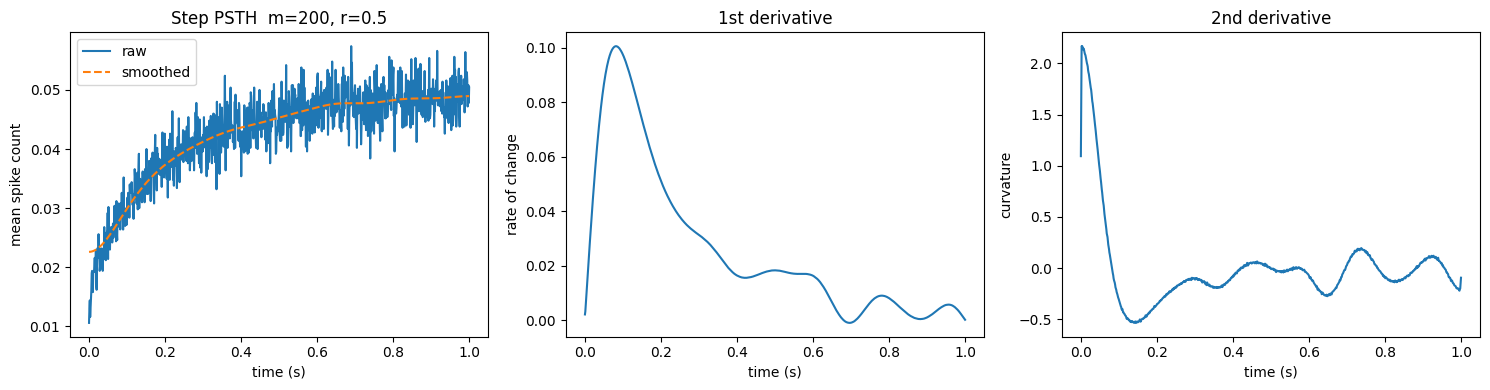

Step PSTH  m=200, r=3                Range =   1.355


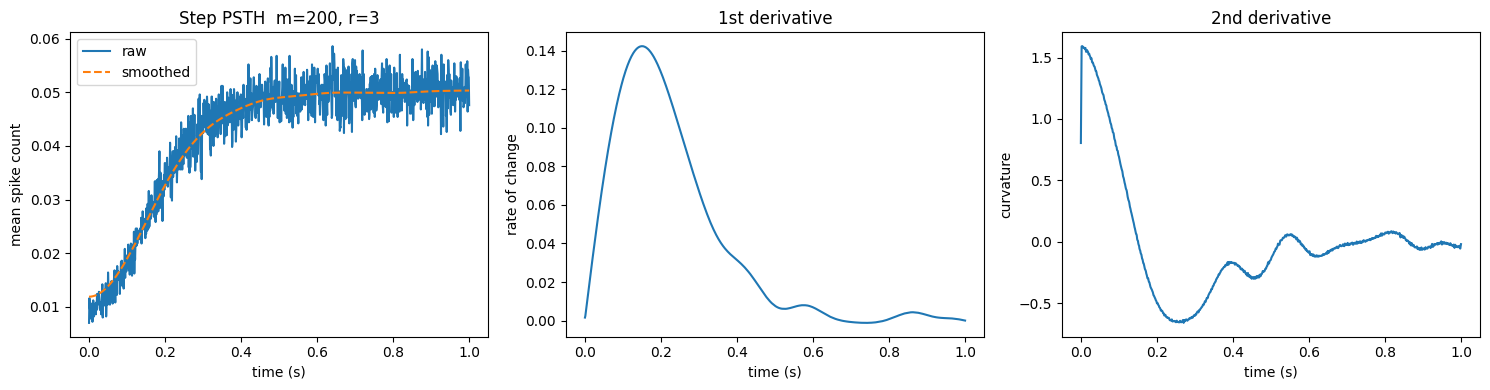

Step PSTH  m=200, r=6                Range =   2.298


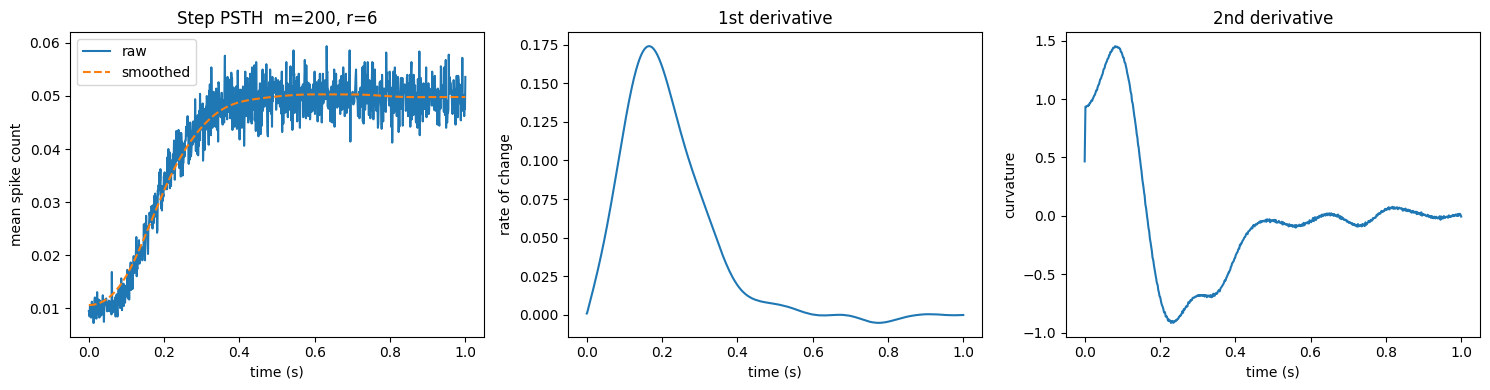

Step PSTH  m=500, r=0.5              Range =   0.336


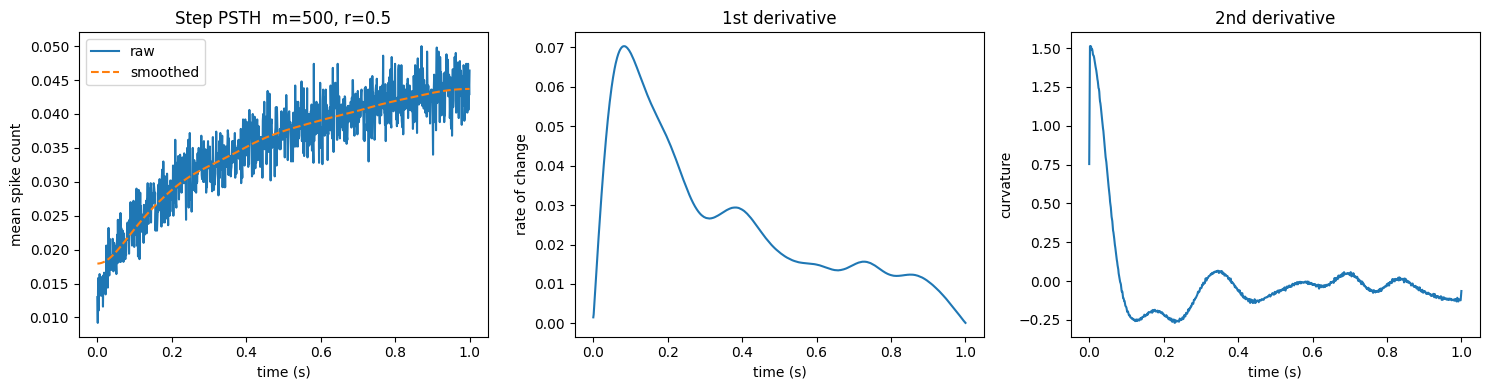

Step PSTH  m=500, r=3                Range =   0.551


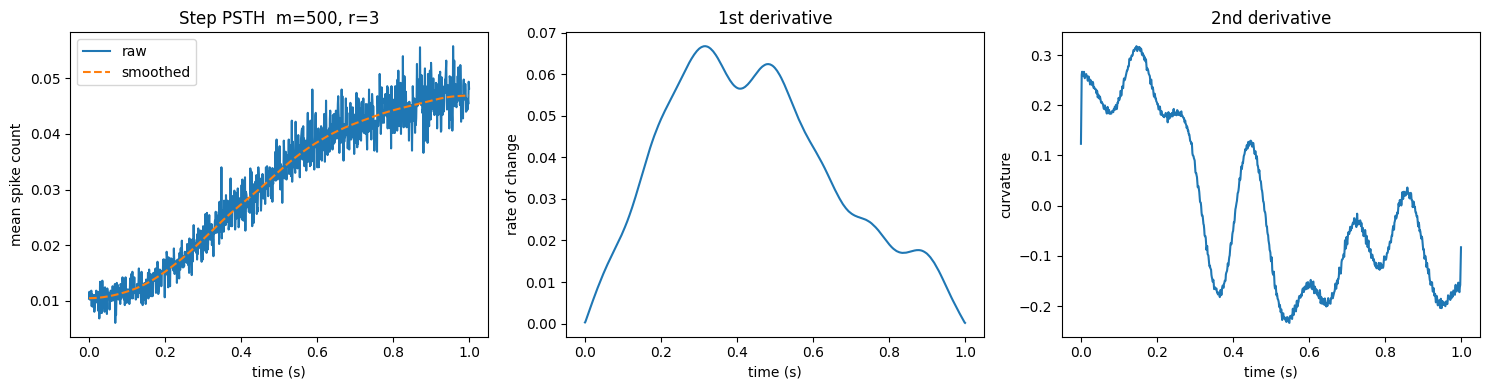

Step PSTH  m=500, r=6                Range =   0.698


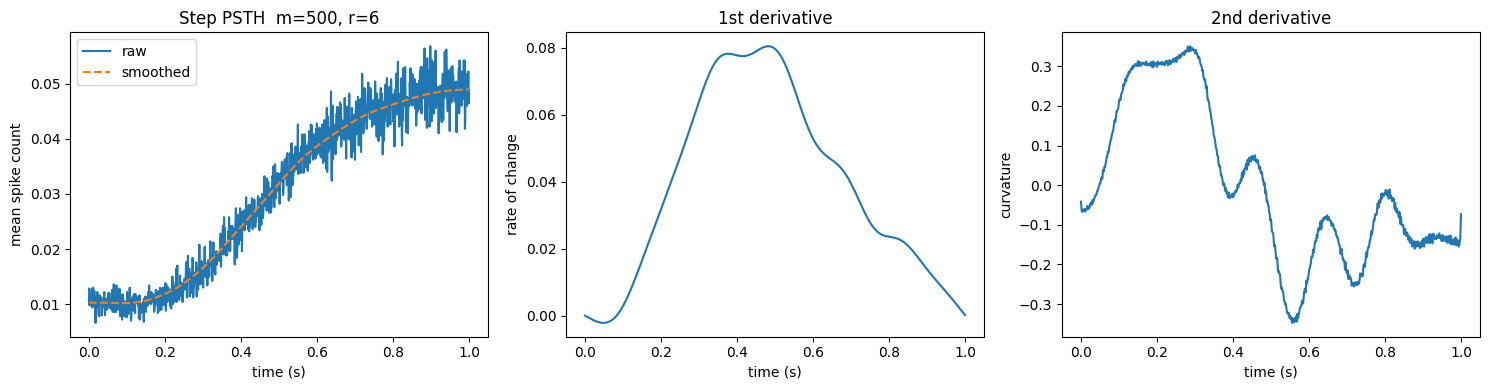

Step PSTH  m=800, r=0.5              Range =   0.359


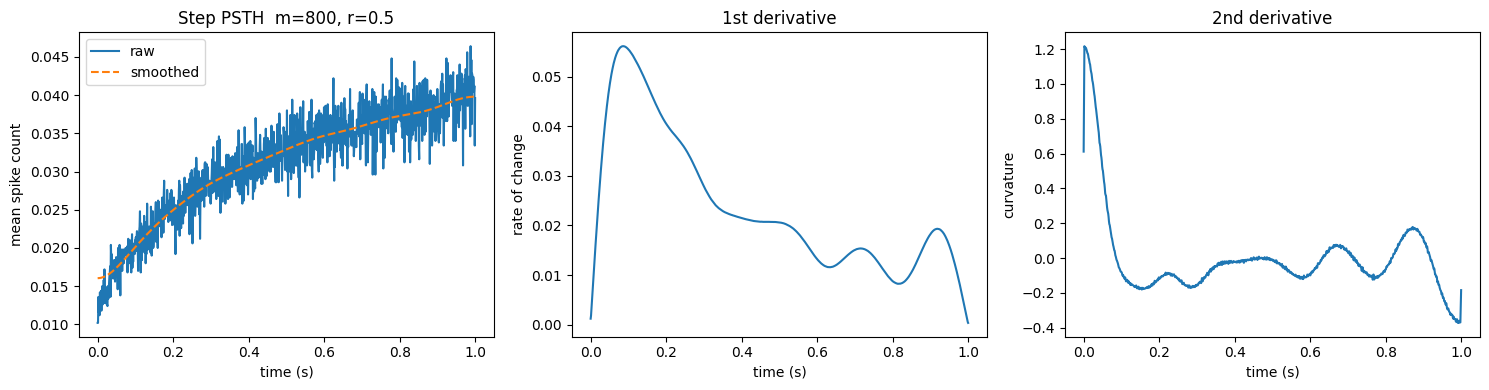

Step PSTH  m=800, r=3                Range =   0.312


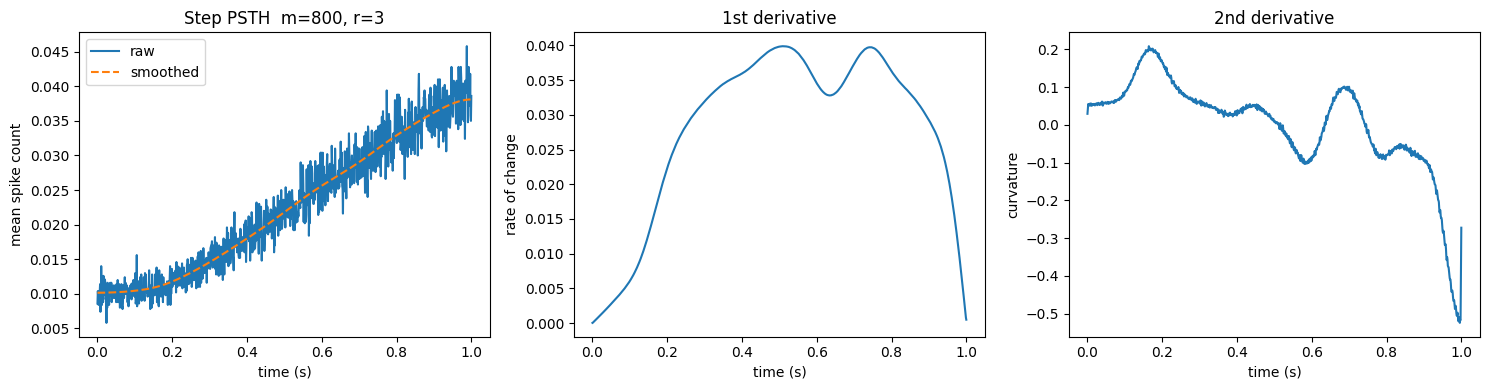

Step PSTH  m=800, r=6                Range =   0.332


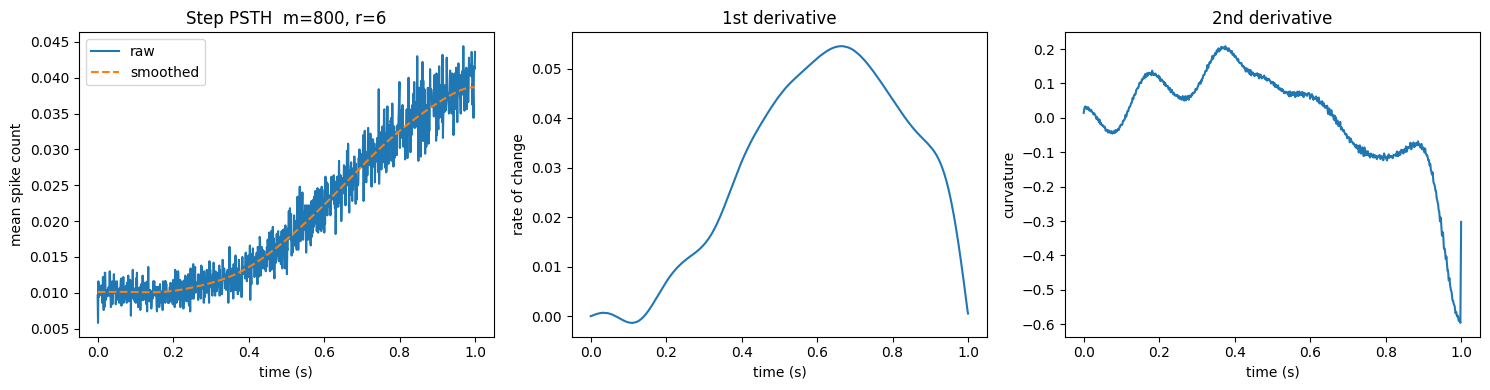

Ramp PSTH β=0, σ=0.04                Range =   0.122


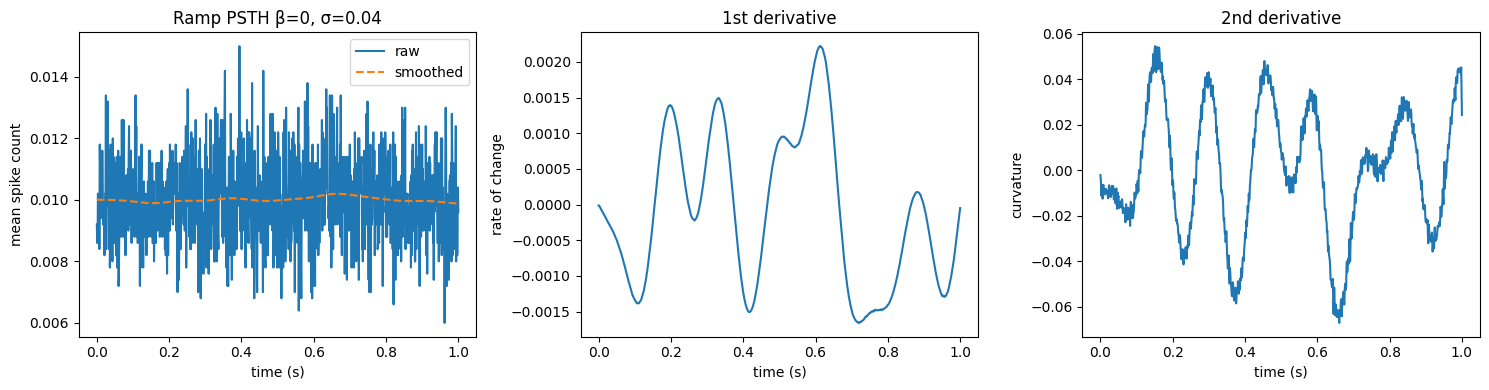

Ramp PSTH β=0, σ=0.4                 Range =   0.170


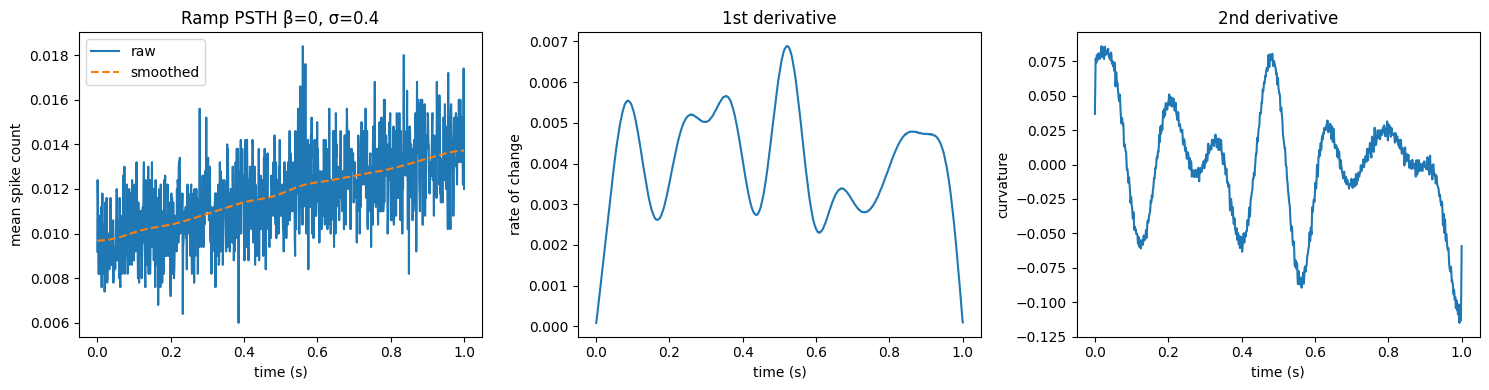

Ramp PSTH β=0, σ=4                   Range =   0.645


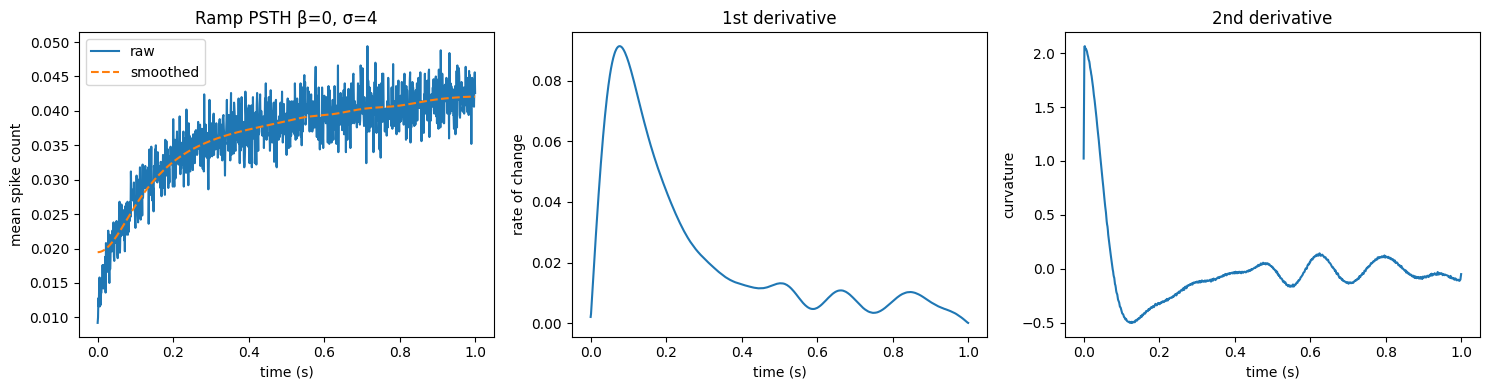

Ramp PSTH β=2, σ=0.04                Range =   0.978


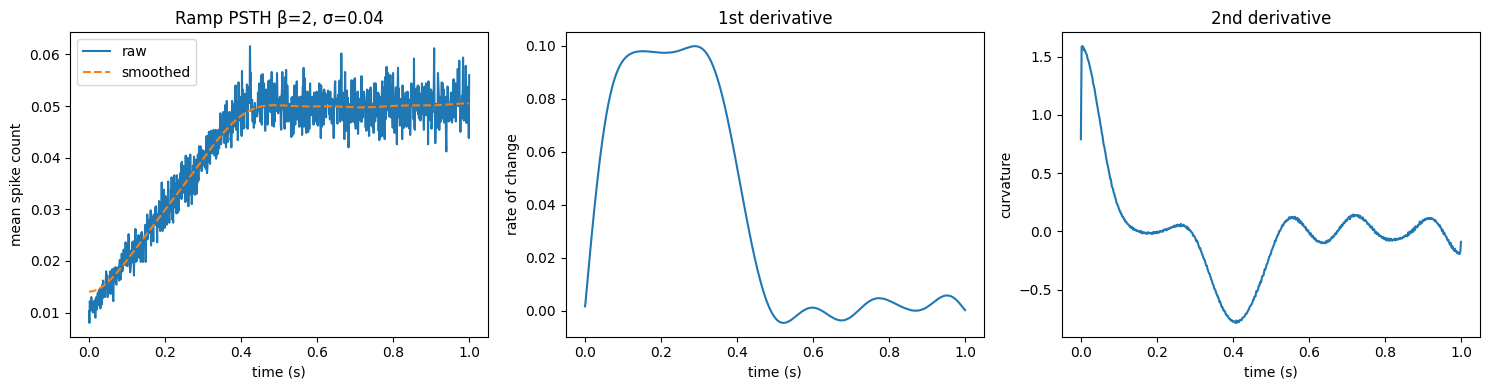

Ramp PSTH β=2, σ=0.4                 Range =   0.602


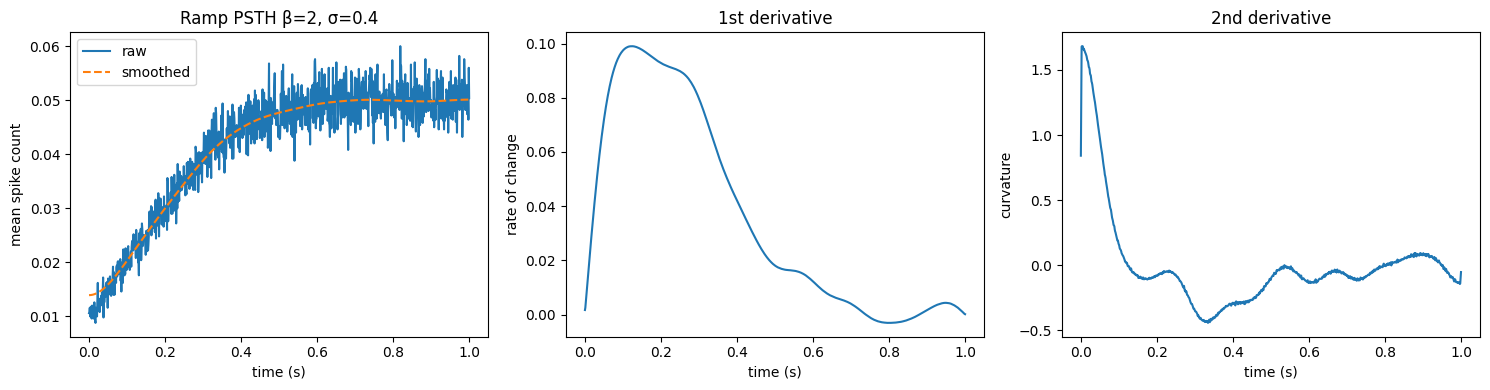

Ramp PSTH β=2, σ=4                   Range =   0.720


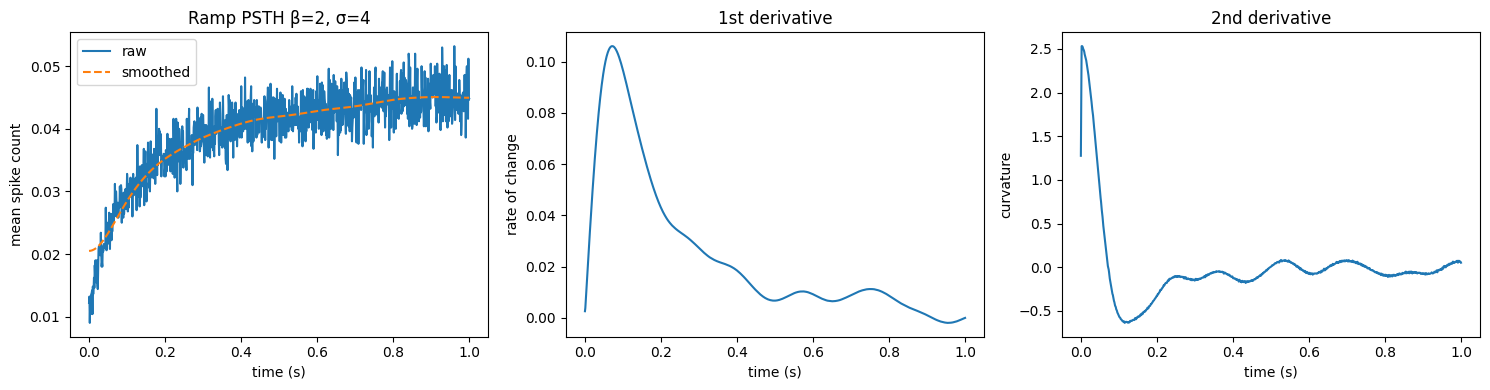

Ramp PSTH β=4, σ=0.04                Range =   1.654


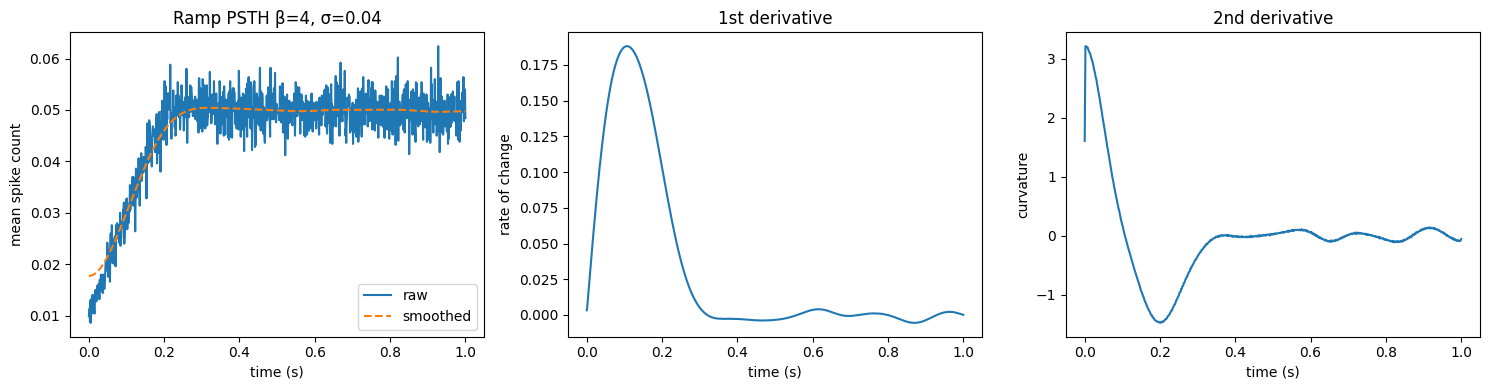

Ramp PSTH β=4, σ=0.4                 Range =   1.384


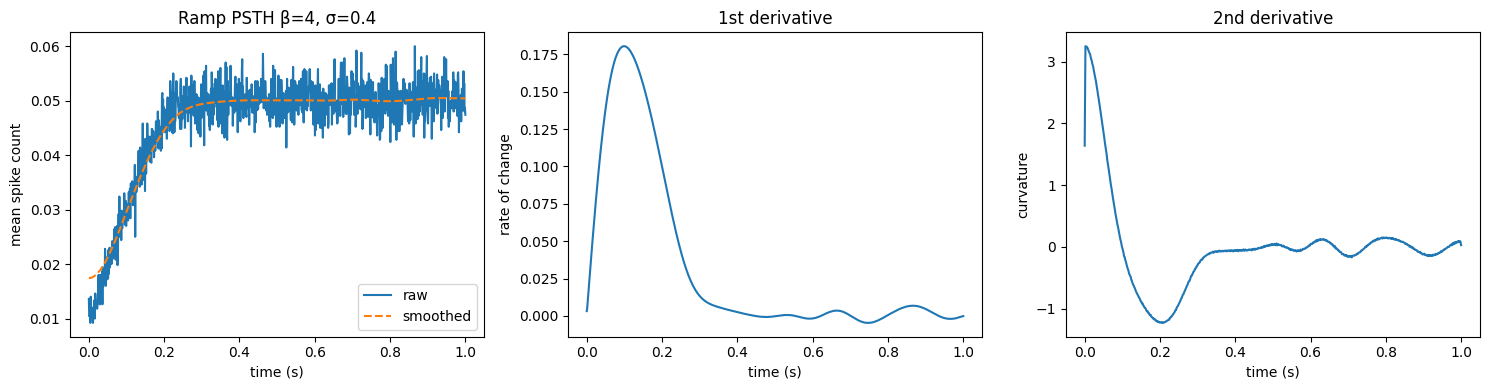

Ramp PSTH β=4, σ=4                   Range =   0.833


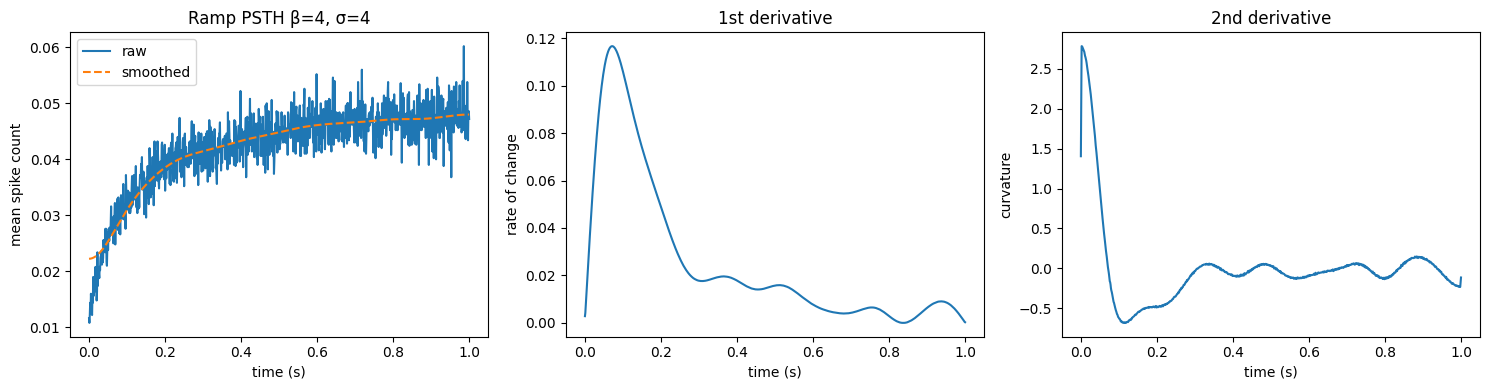

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d


N_TRIALS = 5000
T_BINS = 1000
SIGMA = 50

t_lo, t_hi = 0.1, 0.90 # looking within a certain time range

def analyse(spike_trains, time, title):
    """Return smoothed psth, derivatives and the 2nd-derivative range."""
    dt = time[1] - time[0]
    psth = spike_trains.mean(axis=0)
    psth_smooth = gaussian_filter1d(psth, sigma=SIGMA)
    d1 = np.gradient(psth_smooth, dt)
    d2 = np.gradient(d1, dt)

    # range of 2nd derivative in the chosen window
    win = (time >= t_lo) & (time <= t_hi)
    d2_range = np.ptp(d2[win])
    print(f"{title:<35s}  Range = {d2_range:7.3f}")

    # plotting
    fig, axs = plt.subplots(1, 3, figsize=(15, 4))
    axs[0].plot(time, psth, label='raw')
    axs[0].plot(time, psth_smooth, '--', label='smoothed')
    axs[0].set_title(title); axs[0].legend()
    axs[0].set(xlabel='time (s)', ylabel='mean spike count')

    axs[1].plot(time, d1); axs[1].set_title('1st derivative')
    axs[1].set(xlabel='time (s)', ylabel='rate of change')

    axs[2].plot(time, d2); axs[2].set_title('2nd derivative')
    axs[2].set(xlabel='time (s)', ylabel='curvature')

    fig.tight_layout()
    plt.show()

    return d2_range



for m in [200, 500, 800]:
    for r in [0.5, 3, 6]:
        step_model = StepModel(m=m, r=r)
        spikes, *_ = step_model.simulate(Ntrials=N_TRIALS, T=T_BINS)

        t = np.linspace(0, 1, T_BINS)
        analyse(spikes, t, f"Step PSTH  m={m}, r={r}")


for beta in [0, 2, 4]:
    for sigma in [0.04, 0.4, 4]:
        ramp_model = RampModel(beta=beta, sigma=sigma)
        spikes, *_ = ramp_model.simulate(Ntrials=N_TRIALS, T=T_BINS)

        t = np.linspace(0, 1, T_BINS)
        analyse(spikes, t, f"Ramp PSTH β={beta}, σ={sigma}")


# Task 1.4 PSTH classifier

This classifier simulates datasets from each model, gets their smoothed PSTHs. It extracts the maximum valueof the first derivative of the PSTH, denoted f1, and the max absolute value of the second derivative, denoted f2, returning these as a NumPy array. We then train a logistic classifier based on f1 and f2. The performance is evaluated and a percentage accuracy returned. I think due to inherent sensitivity of the features to noise, the performance is quite variable, ranging within 60-75%.

In [5]:
import numpy as np
from scipy.ndimage import gaussian_filter1d
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from models import StepModel, RampModel

def sample_step_params(T):
    m   = np.random.uniform(T/4, 3*T/4)
    r   = np.random.uniform(0.5, 6.0)
    x0  = np.random.uniform(0.0, 0.5)
    return dict(m=m, r=r, x0=x0)

def sample_ramp_params(): # parameters as given in announcement
    beta  = np.random.uniform(0.0, 4.0)
    lnσ   = np.random.uniform(np.log(0.04), np.log(4.0))
    sigma = np.exp(lnσ)
    x0    = np.random.uniform(0.0, 0.5)
    return dict(beta=beta, sigma=sigma, x0=x0)

def simulate_dataset(model_type, n_trials=400, T=100): # return spikes of shape (n_trials, T) for step or ramp
    if model_type == "step":
        pars  = sample_step_params(T)
        model = StepModel(**pars, Rh=50)
        spikes, *_ = model.simulate(Ntrials=n_trials, T=T, get_rate=False)
    elif model_type == "ramp":
        pars  = sample_ramp_params()
        model = RampModel(**pars, Rh=50)
        spikes, *_ = model.simulate(Ntrials=n_trials, T=T, get_rate=False)
    else:
        raise ValueError("model_type must be 'step' or 'ramp'")
    return spikes.astype(float)

# psth functions
def psth(spikes, smooth_sigma=3):
    mean_counts = spikes.mean(0)
    return gaussian_filter1d(mean_counts, smooth_sigma, mode="nearest")

def dataset_features(spikes): # extract two features: f1 = max 1st derivative and f2 = max absolute 2nd derivative
    p  = psth(spikes)
    d1 = np.diff(p, 1)
    d2 = np.diff(d1, 1)
    f1 = d1.max()
    f2 = np.abs(d2).max()
    return np.array([f1, f2])

# training the classifier
def train_classifier(n_train_each=60, T=100, n_trials=400):
    X, y = [], []
    for label, mtype in enumerate(["step", "ramp"]):
        for _ in range(n_train_each):
            spikes = simulate_dataset(mtype, n_trials=n_trials, T=T)
            X.append(dataset_features(spikes))
            y.append(label)                     # 0 = step, 1 = ramp
    X = np.vstack(X)
    y = np.array(y)

    clf = make_pipeline(StandardScaler(),
                        LogisticRegression(C=1.0, solver="lbfgs"))
    clf.fit(X, y)
    return clf

# evaluating the classifier
def evaluate(clf, n_test_each=40, T=100, n_trials=400):
    correct = 0
    total   = 2 * n_test_each
    for label, mtype in enumerate(["step", "ramp"]):
        for _ in range(n_test_each):
            spikes = simulate_dataset(mtype, n_trials=n_trials, T=T)
            feat   = dataset_features(spikes).reshape(1, -1)
            pred   = clf.predict(feat)[0]
            correct += int(pred == label)
    acc = 100 * correct / total
    print(f"Accuracy: {acc:.1f}%  ({correct}/{total})")
    return acc

# test run
if __name__ == "__main__":
    T = 100    # 1 s trial, 10 ms bins
    n_trials   = 400    # no more than 400 trials per dataset as required
    train_each = 60     # datasets per model for training
    test_each  = 40     # datasets per model for testing

    clf = train_classifier(n_train_each=train_each, T=T, n_trials=n_trials)
    evaluate(clf, n_test_each=test_each, T=T, n_trials=n_trials)


ModuleNotFoundError: No module named 'sklearn'

# Task 1.4 Area Under Fano Classifier

This classifier uses the area-under-curve (AUC) of the Fano factor over time. The AUC is generally larger in the step model. Using this, we generate datasets for step and ramp, and then find a Fano AUC threshold which best separates the distributions (just the midpoint between means). Accuracy is not fantastic - around 60% - could try tuning something? Should provide an explanation of why the accuracy isn't so good

In [ ]:
import numpy as np
from models import StepModel, RampModel

# NOTE: sampling and dataset generation functions defined and used in the PSTH classifier are reused here

# computing the area under Fano
def integrated_fano(spikes, bin_size=10):

    n_trials, T = spikes.shape
    T_trim = T - (T % bin_size)
    binned = spikes[:, :T_trim].reshape(n_trials, -1, bin_size).sum(axis=-1)

    mean = binned.mean(axis=0)
    var  = binned.var(axis=0, ddof=1)

    with np.errstate(divide='ignore', invalid='ignore'):
        fano = np.where(mean > 0, var / mean, 0.0)

    return fano.sum() * bin_size

# training
def train_threshold(n_datasets=500, n_trials=400, T=100, bin_size=10, seed=0):
    """
    Generate n_datasets datasets from each model, compute their AUCs,
    and return a threshold that best separates the two clusters.
    """
    rng = np.random.default_rng(seed)
    auc_step = []
    auc_ramp = []
    for _ in range(n_datasets):
        spikes = simulate_dataset("step", n_trials, T)
        auc_step.append(integrated_fano(spikes, bin_size))
        spikes = simulate_dataset("ramp", n_trials, T)
        auc_ramp.append(integrated_fano(spikes, bin_size))

    auc_step = np.array(auc_step)
    auc_ramp = np.array(auc_ramp)

    # simple midpoint between the two means
    threshold = 0.5 * (auc_step.mean() + auc_ramp.mean())
    return threshold, auc_step, auc_ramp


def classify_dataset(spikes, threshold, bin_size=10):
    auc = integrated_fano(spikes, bin_size)
    return "step" if auc >= threshold else "ramp"


# function to evaluate accuracy
def evaluate(threshold, n_datasets=100, n_trials=400, T=100, bin_size=10):
    correct = 0
    total   = 2 * n_datasets  # one from each model per loop
    for _ in range(n_datasets):
        if classify_dataset(simulate_dataset("step", n_trials, T),  threshold, bin_size) == "step":
            correct += 1
        if classify_dataset(simulate_dataset("ramp", n_trials, T),  threshold, bin_size) == "ramp":
            correct += 1
    return 100 * correct / total


# test
if __name__ == "__main__":
    THRESH, train_step_auc, train_ramp_auc = train_threshold()
    acc = evaluate(THRESH)
    print(f"Decision threshold (AUC): {THRESH:.1f}")
    print(f"Classification accuracy on fresh test-sets: {acc:.1f}%")


Decision threshold (AUC): 152.4
Classification accuracy on fresh test-sets: 57.5%
